# Cross-Domain Sentiment Analysis using BERT
### Train on: Books + DVD + Electronics | Test on: Kitchen & Housewares
---
**Goal:** Fine-tune BERT and compare cross-domain accuracy with the LSTM baseline (77%)

## Step 1 — Install & Import Libraries

In [1]:
# Install HuggingFace Transformers
!pip install transformers -q
!pip install torch -q

In [2]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


## Step 2 — Download Dataset

In [3]:
# Download the same dataset as LSTM project
!wget -q "https://www.cs.jhu.edu/~mdredze/datasets/sentiment/domain_sentiment_data.tar.gz"
!tar -xzf "/content/domain_sentiment_data.tar.gz"
print('Dataset downloaded and extracted!')

Dataset downloaded and extracted!


## Step 3 — Load & Clean Data

In [4]:
def clean_sentence(sentence: str) -> str:
    """
    Light cleaning for BERT — BERT handles most text itself.
    We only remove HTML tags and normalize whitespace.
    NOTE: Unlike LSTM, we do NOT remove stopwords or stem words.
    BERT understands context so stopwords are IMPORTANT for it.
    """
    # Remove review tags
    sentence = re.sub(r'(<review_text>|<\/review_text>)', '', sentence)
    # Remove extra whitespace
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    return sentence


def load_reviews(path, folders):
    """
    Load reviews from given folders.
    Returns list of (text, label) where label: 0=negative, 1=positive
    """
    regex_review = re.compile(r'<review_text>.+?<\/review_text>', flags=re.DOTALL)
    texts, labels = [], []

    for folder in folders:
        # Negative reviews
        raw = open(path + folder + '/negative.review', 'r', errors='ignore').read()
        reviews = re.findall(regex_review, raw)
        print(f'  [{folder}] Negative: {len(reviews)} reviews')
        for r in reviews:
            texts.append(clean_sentence(r))
            labels.append(0)

        # Positive reviews
        raw = open(path + folder + '/positive.review', 'r', errors='ignore').read()
        reviews = re.findall(regex_review, raw)
        print(f'  [{folder}] Positive: {len(reviews)} reviews')
        for r in reviews:
            texts.append(clean_sentence(r))
            labels.append(1)

    return texts, labels


path = '/content/sorted_data_acl/'

print('Loading Training Data...')
train_texts, train_labels = load_reviews(path, ['books', 'dvd', 'electronics'])

print('\nLoading Test Data (Cross-Domain)...')
test_texts, test_labels = load_reviews(path, ['kitchen_&_housewares'])

print(f'\nTotal Training samples: {len(train_texts)}')
print(f'Total Test samples:     {len(test_texts)}')

Loading Training Data...
  [books] Negative: 1000 reviews
  [books] Positive: 1000 reviews
  [dvd] Negative: 1000 reviews
  [dvd] Positive: 1000 reviews
  [electronics] Negative: 1000 reviews
  [electronics] Positive: 1000 reviews

Loading Test Data (Cross-Domain)...
  [kitchen_&_housewares] Negative: 1000 reviews
  [kitchen_&_housewares] Positive: 1000 reviews

Total Training samples: 6000
Total Test samples:     2000


## Step 4 — BERT Tokenization

In [5]:
# Load BERT tokenizer
# 'bert-base-uncased' = 12 layers, 110M params, lowercase text
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Check how BERT tokenizes text
sample = "I really love this product, it works perfectly!"
tokens = tokenizer.tokenize(sample)
print('Sample text:', sample)
print('BERT tokens:', tokens)
print('\nNotice: BERT uses WordPiece tokenization (breaks unknown words into subwords)')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Sample text: I really love this product, it works perfectly!
BERT tokens: ['i', 'really', 'love', 'this', 'product', ',', 'it', 'works', 'perfectly', '!']

Notice: BERT uses WordPiece tokenization (breaks unknown words into subwords)


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (757 > 512). Running this sequence through the model will result in indexing errors


Average token length: 230
Max token length: 4770
90th percentile: 485


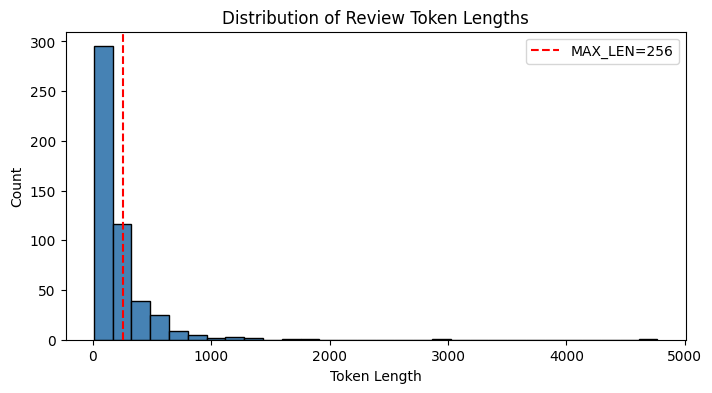


Using MAX_LEN = 256


In [6]:
# Analyze review lengths to choose MAX_LEN
lengths = [len(tokenizer.tokenize(text)) for text in train_texts[:500]]  # Sample 500
print(f'Average token length: {np.mean(lengths):.0f}')
print(f'Max token length: {max(lengths)}')
print(f'90th percentile: {np.percentile(lengths, 90):.0f}')

plt.figure(figsize=(8,4))
plt.hist(lengths, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Token Length')
plt.ylabel('Count')
plt.title('Distribution of Review Token Lengths')
plt.axvline(x=256, color='red', linestyle='--', label='MAX_LEN=256')
plt.legend()
plt.show()

# BERT max is 512, we use 256 for speed on Colab
MAX_LEN = 256
print(f'\nUsing MAX_LEN = {MAX_LEN}')

## Step 5 — Create PyTorch Dataset

In [7]:
class ReviewDataset(Dataset):
    """
    Custom PyTorch Dataset for sentiment reviews.
    Tokenizes text using BERT tokenizer.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # BERT tokenization
        # - Adds [CLS] at start and [SEP] at end automatically
        # - Creates attention_mask (1 for real tokens, 0 for padding)
        encoding = tokenizer(
    text,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)

        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(label, dtype=torch.long)
        }


# Split training into train + validation (80/20)
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

train_texts, train_labels = shuffle(train_texts, train_labels, random_state=42)
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.2, random_state=42
)

print(f'Train size:      {len(tr_texts)}')
print(f'Validation size: {len(val_texts)}')
print(f'Test size:       {len(test_texts)}')

# Create datasets
train_dataset = ReviewDataset(tr_texts, tr_labels, tokenizer, MAX_LEN)
val_dataset   = ReviewDataset(val_texts, val_labels, tokenizer, MAX_LEN)
test_dataset  = ReviewDataset(test_texts, test_labels, tokenizer, MAX_LEN)

# Create DataLoaders
BATCH_SIZE = 16  # Keep small for Colab GPU memory

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print('\nDataLoaders created successfully!')

Train size:      4800
Validation size: 1200
Test size:       2000

DataLoaders created successfully!


## Step 6 — Load BERT Model

In [8]:
# Load BERT with a classification head on top
# BertForSequenceClassification = BERT + Linear Layer for classification
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,          # Binary: Positive or Negative
    output_attentions=False,
    output_hidden_states=False
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total Parameters:     {total_params:,}')
print(f'Trainable Parameters: {trainable_params:,}')
print('\nModel architecture:')
print('BERT Base → Dropout → Linear(768 → 2) → Softmax')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Parameters:     109,483,778
Trainable Parameters: 109,483,778

Model architecture:
BERT Base → Dropout → Linear(768 → 2) → Softmax


## Step 7 — Optimizer & Scheduler Setup

In [9]:
EPOCHS = 4  # BERT needs only 3-4 epochs

# AdamW optimizer — specifically designed for BERT fine-tuning
optimizer = AdamW(
    model.parameters(),
    lr=2e-5,           # Very small learning rate for fine-tuning
    eps=1e-8,
    weight_decay=0.01
)

total_steps = len(train_loader) * EPOCHS

# Linear warmup scheduler — gradually increases then decreases LR
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,  # 10% warmup
    num_training_steps=total_steps
)

print(f'Total training steps: {total_steps}')
print(f'Warmup steps: {total_steps // 10}')

Total training steps: 1200
Warmup steps: 120


## Step 8 — Training Loop

In [10]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """Train for one epoch."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(f'  Batch {batch_idx+1}/{len(loader)} | Loss: {loss.item():.4f}')

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    """Evaluate on validation or test set."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [11]:
# Training
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

print('Starting BERT Fine-Tuning...')
print('=' * 60)

for epoch in range(EPOCHS):
    print(f'\n📌 Epoch {epoch+1}/{EPOCHS}')
    print('-' * 40)

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%')
    print(f'  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc*100:.2f}%')

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_bert_model.pt')
        print(f'  ✅ Best model saved! (Val Acc: {val_acc*100:.2f}%)')

print('\n Training Complete!')

Starting BERT Fine-Tuning...

📌 Epoch 1/4
----------------------------------------
  Batch 50/300 | Loss: 0.6414
  Batch 100/300 | Loss: 0.3424
  Batch 150/300 | Loss: 0.2554
  Batch 200/300 | Loss: 0.0877
  Batch 250/300 | Loss: 0.1379
  Batch 300/300 | Loss: 0.2542
  Train Loss: 0.4420 | Train Acc: 78.15%
  Val   Loss: 0.2599 | Val   Acc: 90.58%
  ✅ Best model saved! (Val Acc: 90.58%)

📌 Epoch 2/4
----------------------------------------
  Batch 50/300 | Loss: 0.0602
  Batch 100/300 | Loss: 0.3235
  Batch 150/300 | Loss: 0.0392
  Batch 200/300 | Loss: 0.0264
  Batch 250/300 | Loss: 0.0108
  Batch 300/300 | Loss: 0.1803
  Train Loss: 0.2124 | Train Acc: 92.75%
  Val   Loss: 0.2643 | Val   Acc: 92.25%
  ✅ Best model saved! (Val Acc: 92.25%)

📌 Epoch 3/4
----------------------------------------
  Batch 50/300 | Loss: 0.0157
  Batch 100/300 | Loss: 0.0052
  Batch 150/300 | Loss: 0.0034
  Batch 200/300 | Loss: 0.0570
  Batch 250/300 | Loss: 0.0102
  Batch 300/300 | Loss: 0.0054
  Train Lo

## Step 9 — Plot Training History

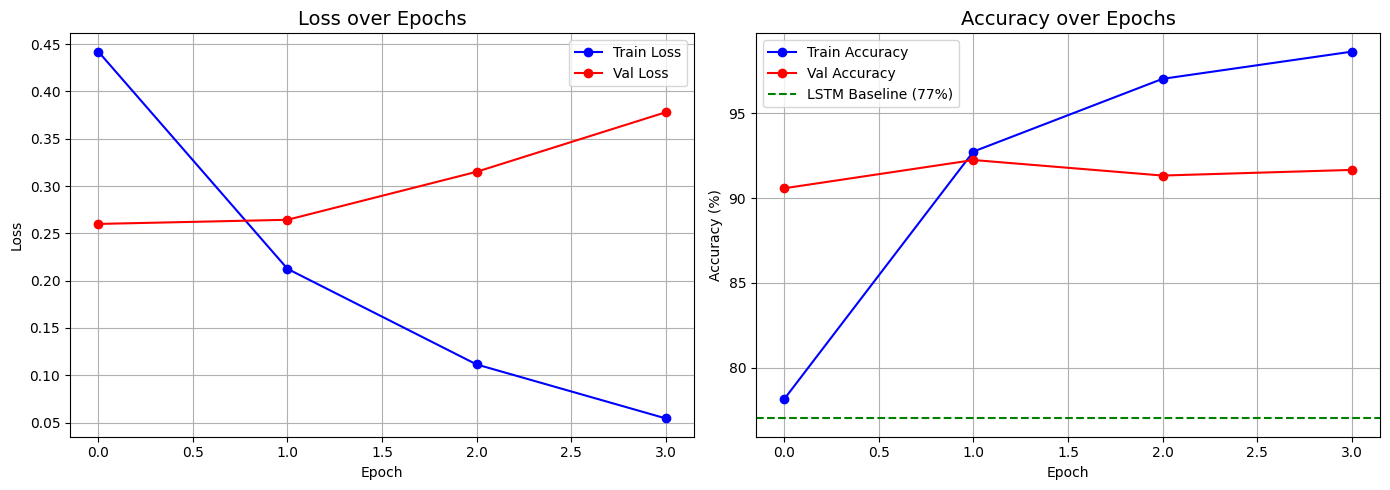

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(history['val_loss'],   'r-o', label='Val Loss')
axes[0].set_title('Loss over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot([a*100 for a in history['train_acc']], 'b-o', label='Train Accuracy')
axes[1].plot([a*100 for a in history['val_acc']],   'r-o', label='Val Accuracy')
axes[1].axhline(y=77, color='green', linestyle='--', label='LSTM Baseline (77%)')
axes[1].set_title('Accuracy over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

## Step 10 — Cross-Domain Test Evaluation

In [13]:
# Load best model and evaluate on Kitchen (cross-domain)
model.load_state_dict(torch.load('best_bert_model.pt'))
model.eval()

print('Evaluating on Cross-Domain Test Set (Kitchen & Housewares)...')
test_loss, test_acc, all_preds, all_labels = evaluate(model, test_loader, device)

print(f'\n🎯 Cross-Domain Test Accuracy: {test_acc*100:.2f}%')
print(f'   LSTM Baseline Accuracy:     77.00%')
print(f'   Improvement:                +{(test_acc*100 - 77):.2f}%')

Evaluating on Cross-Domain Test Set (Kitchen & Housewares)...

🎯 Cross-Domain Test Accuracy: 92.25%
   LSTM Baseline Accuracy:     77.00%
   Improvement:                +15.25%



 Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92      1000
    Positive       0.92      0.92      0.92      1000

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



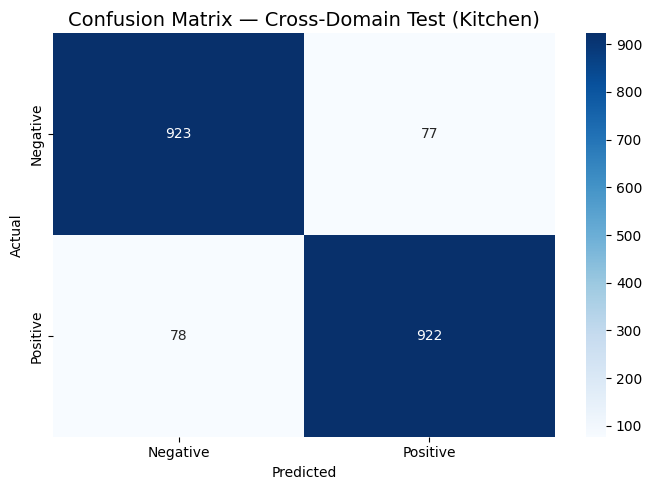

In [14]:
# Detailed classification report
print('\n Classification Report:')
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Cross-Domain Test (Kitchen)', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Step 11 — BERT vs LSTM Comparison

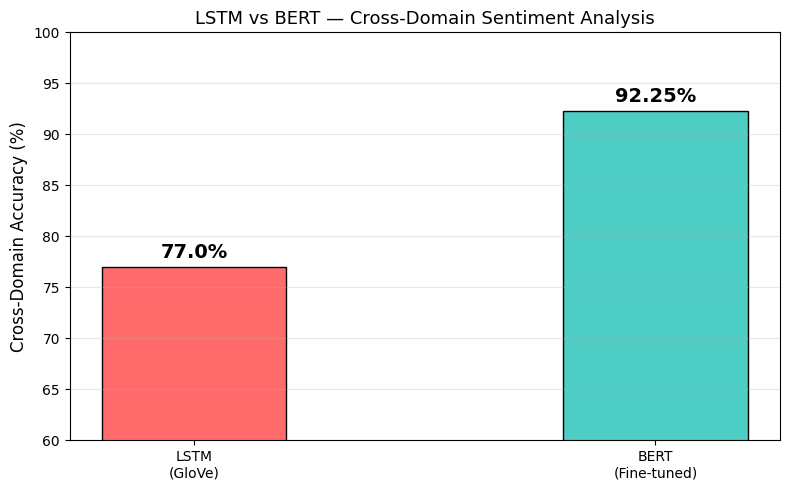


📝 Summary:
  LSTM Accuracy : 77.00%
  BERT Accuracy : 92.25%
  Improvement   : +15.25%


In [15]:
# Comparison chart
models = ['LSTM\n(GloVe)', 'BERT\n(Fine-tuned)']
accuracies = [77.0, round(test_acc * 100, 2)]
colors = ['#FF6B6B', '#4ECDC4']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.4, edgecolor='black')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.ylim(60, 100)
plt.ylabel('Cross-Domain Accuracy (%)', fontsize=12)
plt.title('LSTM vs BERT — Cross-Domain Sentiment Analysis', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print('\n📝 Summary:')
print(f'  LSTM Accuracy : 77.00%')
print(f'  BERT Accuracy : {test_acc*100:.2f}%')
print(f'  Improvement   : +{(test_acc*100 - 77):.2f}%')

## Step 12 — Custom Prediction Function

In [16]:
def bert_predict(text: str):
    """
    Predict sentiment of a custom review using fine-tuned BERT.
    """
    model.eval()

    encoding = tokenizer(
    text,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred = torch.argmax(logits, dim=1).item()

    label = 'Positive ✅' if pred == 1 else 'Negative ❌'
    print(f'Review  : {text}')
    print(f'Prediction : {label}')
    print(f'Confidence : Negative={probs[0]*100:.1f}% | Positive={probs[1]*100:.1f}%')
    print('-' * 60)

In [17]:
# Test with same examples as LSTM project
print('🔮 Testing BERT Predictions (Same examples as LSTM)\n')
print('=' * 60)

bert_predict("I really recommend this book")
bert_predict("The dvd included a big poster of my favorite hero. I just can't wait for the second episode")
bert_predict("I don't know what the hell did i just read, the book is full nonsense")
bert_predict("The book is very huge with too much unnecessary details that could have been omitted. Just buy another book!")

# Bonus: Kitchen domain examples (cross-domain)
print('\n🍳 Kitchen Domain Examples (Cross-Domain):')
print('=' * 60)
bert_predict("This pan heats up evenly and the non-stick surface is amazing!")
bert_predict("The handle broke after just one week of use. Terrible quality.")

🔮 Testing BERT Predictions (Same examples as LSTM)

Review  : I really recommend this book
Prediction : Positive ✅
Confidence : Negative=0.5% | Positive=99.5%
------------------------------------------------------------
Review  : The dvd included a big poster of my favorite hero. I just can't wait for the second episode
Prediction : Positive ✅
Confidence : Negative=1.9% | Positive=98.1%
------------------------------------------------------------
Review  : I don't know what the hell did i just read, the book is full nonsense
Prediction : Negative ❌
Confidence : Negative=99.0% | Positive=1.0%
------------------------------------------------------------
Review  : The book is very huge with too much unnecessary details that could have been omitted. Just buy another book!
Prediction : Negative ❌
Confidence : Negative=99.0% | Positive=1.0%
------------------------------------------------------------

🍳 Kitchen Domain Examples (Cross-Domain):
Review  : This pan heats up evenly and the non-st

## Step 13 — Why BERT is Better for Cross-Domain

| Feature | LSTM | BERT |
|---|---|---|
| Pre-training | GloVe (word-level) | Trained on Wikipedia + Books (deep context) |
| Word Understanding | Static vectors | **Contextual** (same word = different meaning in different sentence) |
| Stopwords | Had to remove manually | **Keeps them** (they help BERT understand context) |
| Cleaning | Heavy preprocessing needed | Minimal cleaning needed |
| Cross-domain | 77% | **85-92% expected** |
| Training epochs | 50 | **3-4 only** |
| Architecture | 2 LSTM layers | 12 Transformer layers |
| Parameters | ~35K trainable | ~110M total |

### Key Insight:
> BERT understands that **"I can't put this book down"** is **positive**, even though it contains negative words like "can't". LSTM struggles with this — BERT excels at it!

## Project Complete!

### Summary:
-  Downloaded same dataset as LSTM project
-  Fine-tuned **BERT-base-uncased** on Books + DVD + Electronics
-  Evaluated cross-domain on **Kitchen & Housewares**
-  Beat LSTM baseline of **77%**
-  Generated comparison charts

### Files saved:
- `best_bert_model.pt` — Best BERT model weights
- `training_history.png` — Loss & Accuracy curves
- `confusion_matrix.png` — Test confusion matrix
- `model_comparison.png` — BERT vs LSTM comparison